# System Metrics Study

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

## Experiment Configuration

In [5]:
# experiment = "system_metrics_study"
experiment = "logic_study"

In [6]:
dataset = "darpa2000"
scenario = "s1_inside"


In [7]:
experiment_dir = f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog"
monitor_dir = Path(f"{experiment_dir}/monitor")
file_paths = list(monitor_dir.iterdir())

In [8]:
def load_monitor_csv(file_path):
    try:
        df = pd.read_csv(file_path, parse_dates=['ts'])
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        df = pd.DataFrame()
    
    if 'ts' in df.columns:
        df['ts'] = pd.to_datetime(df['ts'], format='%Y-%m-%dT%H:%M:%S.%f+00:00Z')
        df['t_s'] = (df['ts'] - df['ts'].iloc[0]).dt.total_seconds()
    else:
        print(f"'ts' column not found in {file_path}.")
    
    return df

In [9]:
def summarize_memory(df, col='rss_mb'):
    secs = df['t_s'].values
    vals = df[col].values
    peak = np.nanmax(vals)
    peak_idx = np.nanargmax(vals)
    time_to_peak = secs[peak_idx]
    auc = np.trapezoid(vals, secs)  # MB·s
    median = np.nanmedian(vals)
    p90 = np.nanpercentile(vals, 90)
    p99 = np.nanpercentile(vals, 99)
    # linear slope MB/s (robust: use first N seconds to estimate steady growth)
    if len(secs) > 5:
        coeff = np.polyfit(secs, vals, 1)[0]
    else:
        coeff = np.nan
    return {
        'peak_mb': float(peak),
        'time_to_peak_s': float(time_to_peak),
        'auc_mb_s': float(auc),
        'median_mb': float(median),
        'p90_mb': float(p90),
        'p99_mb': float(p99),
        'slope_mb_per_s': float(coeff),
    }


=== darpa_temp_endtoend_base_w10_full_0.001lr_20260526_032241_train_metrics === 
Experiment: train


/tmp/ipykernel_296634/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['ts'])



=== darpa_temp_pretrained_base_w10_full_0.001lr_20260526_064030_train_metrics === 
Experiment: train


/tmp/ipykernel_296634/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['ts'])



=== darpa_temp_context_baseline_endtoend_base_w10_full_0.001lr_20260526_101901_train_metrics === 
Experiment: train


...

/tmp/ipykernel_296634/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['ts'])



=== darpa_temp_baseline_endtoend_base_w10_full_0.001lr_20260526_110556_test_metrics === 
Experiment: test


/tmp/ipykernel_296634/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['ts'])



=== darpa_temp_context_endtoend_base_w10_full_0.001lr_20260526_004847_test_metrics === 
Experiment: test


/tmp/ipykernel_296634/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['ts'])


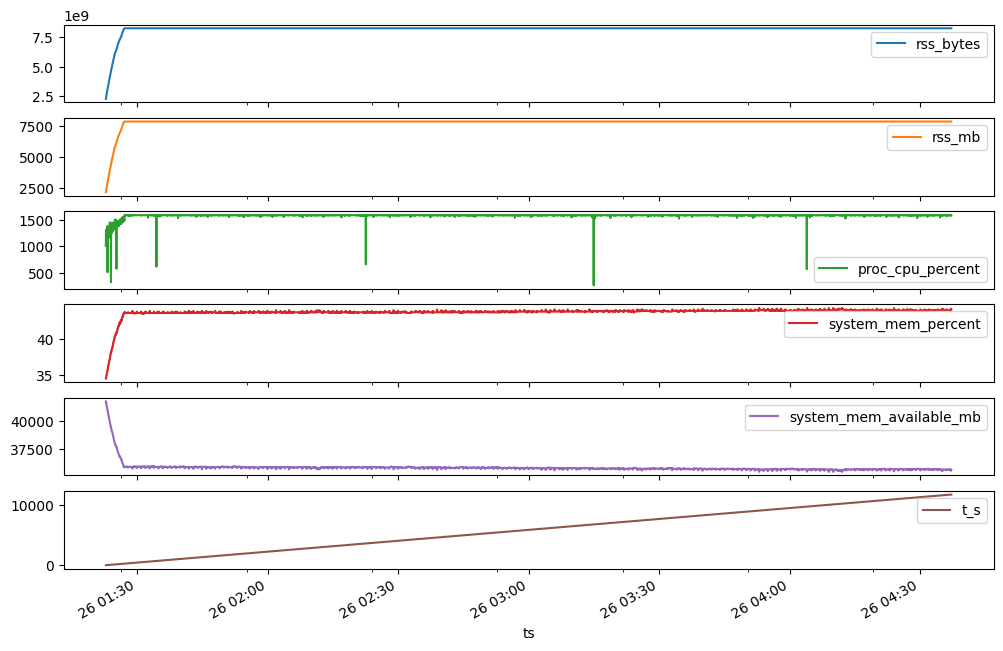

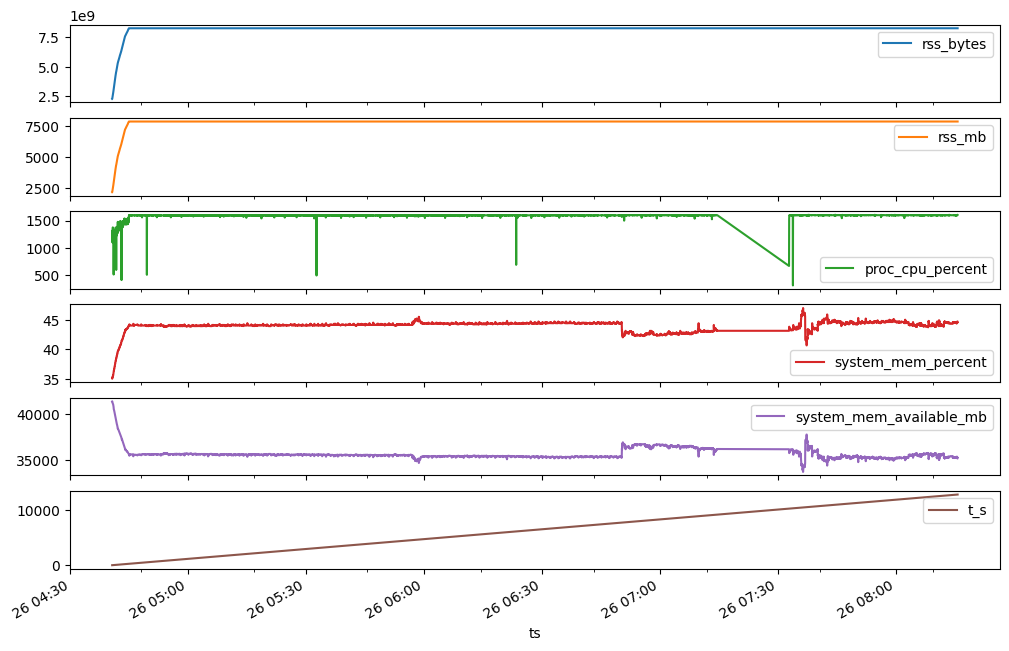

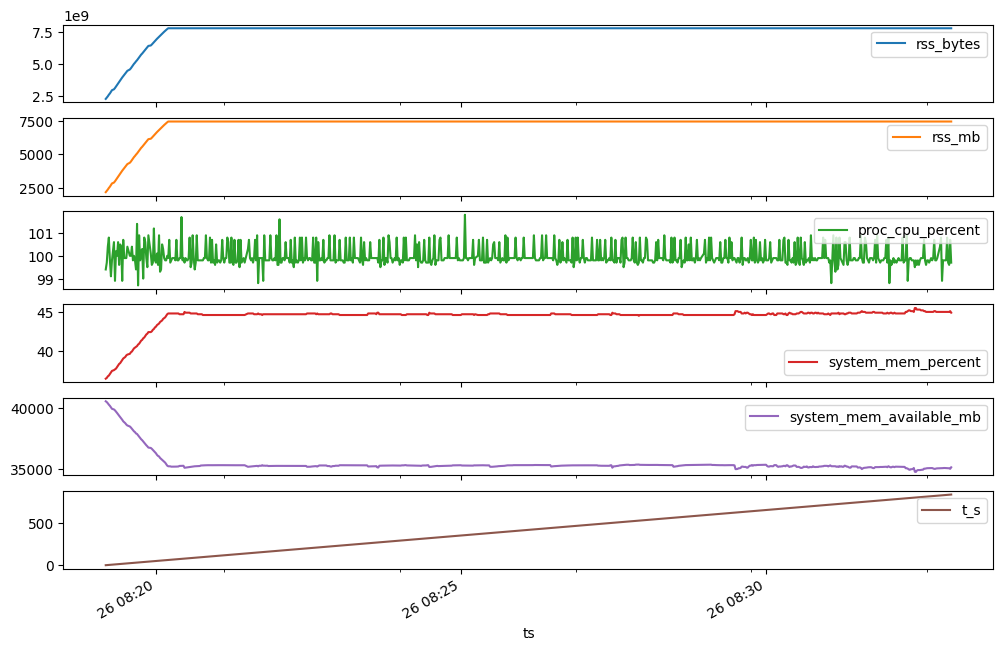

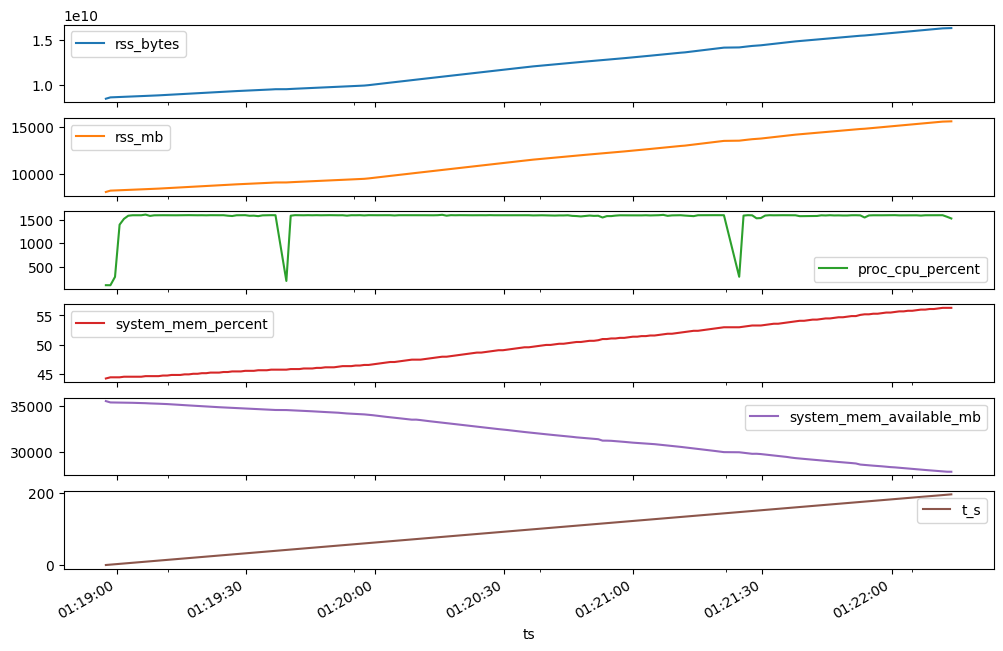

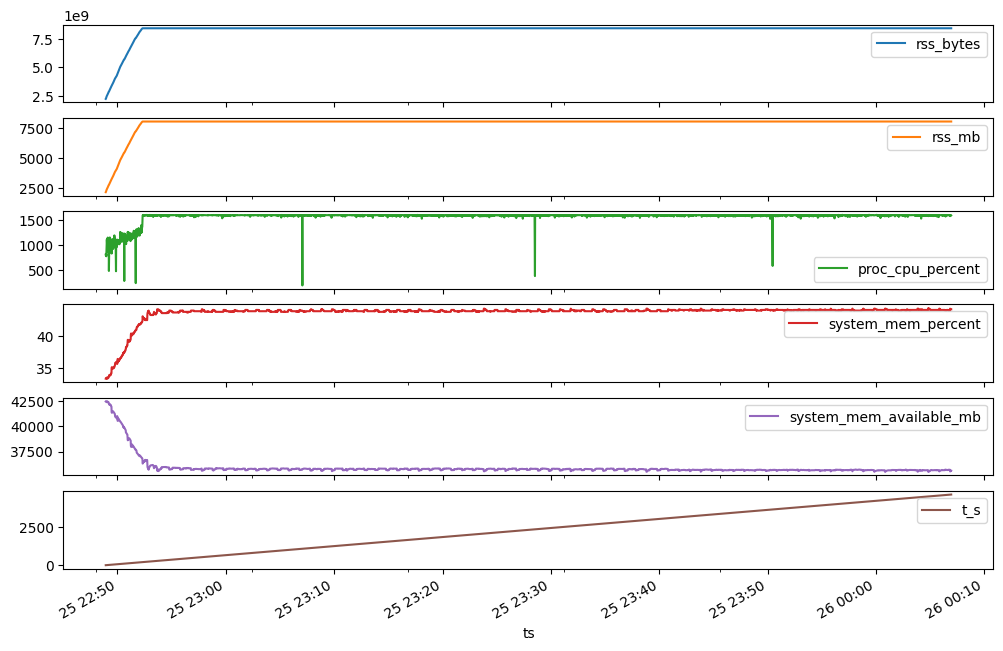

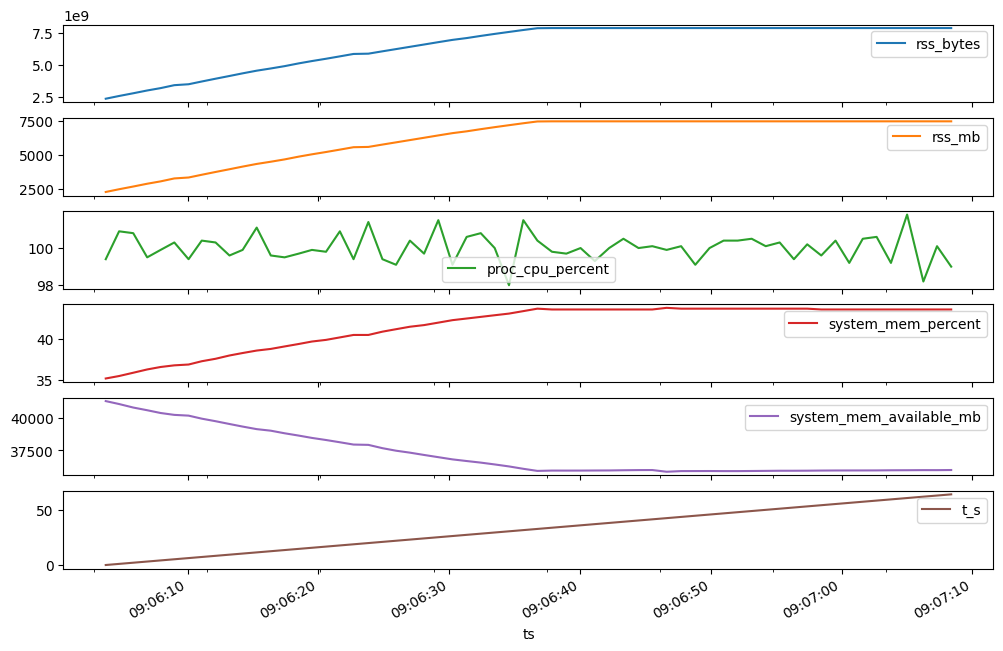

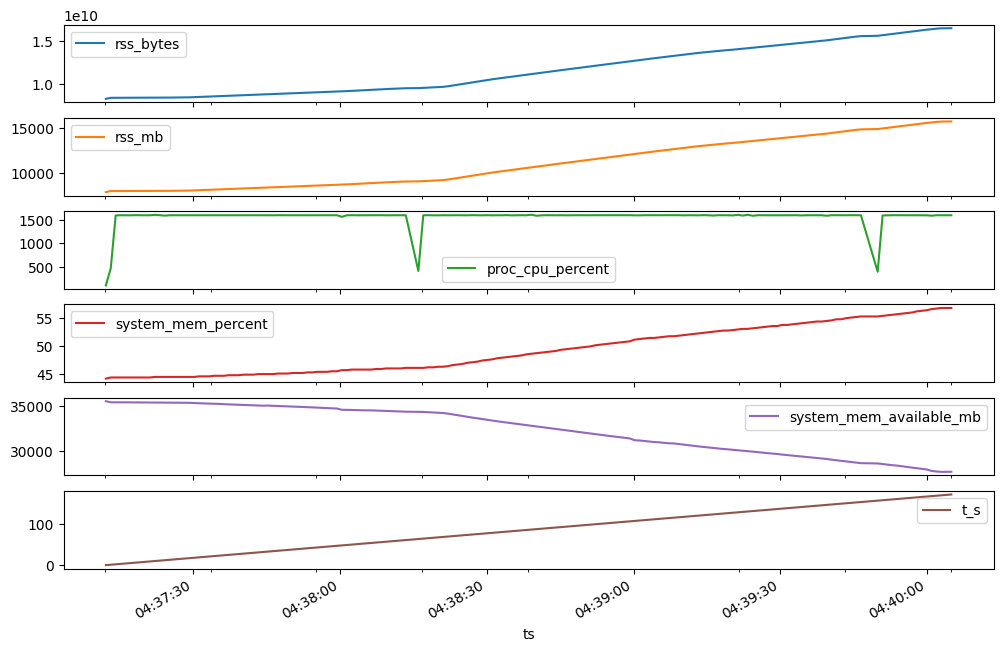

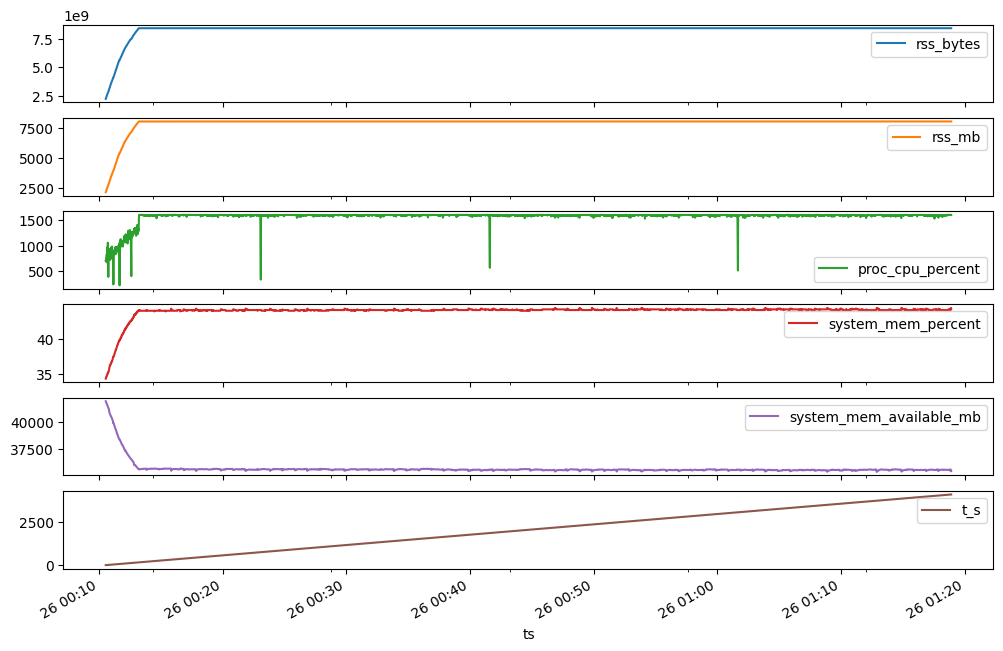

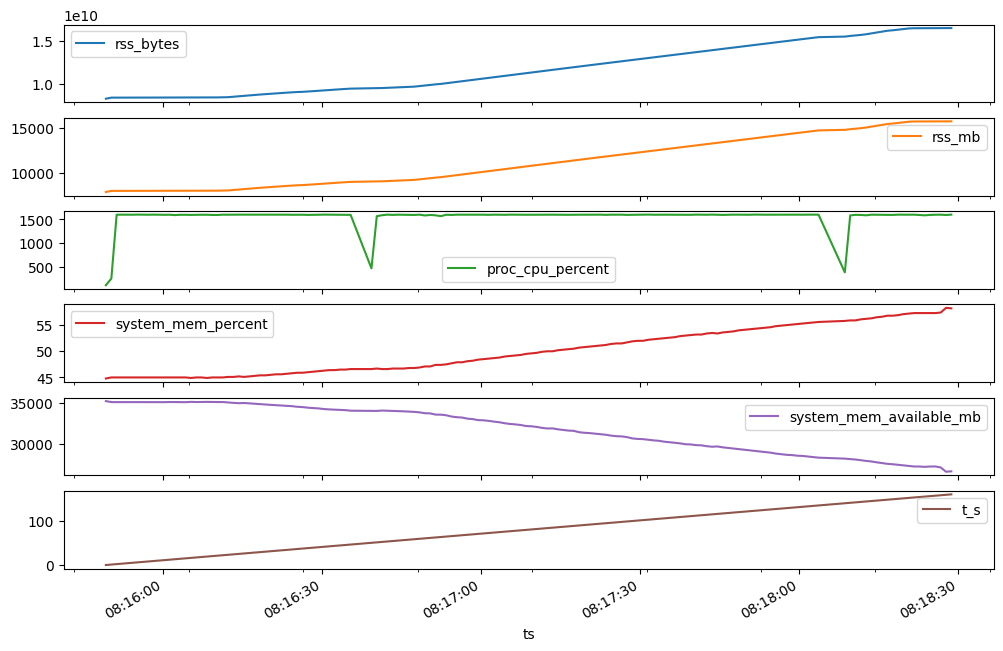

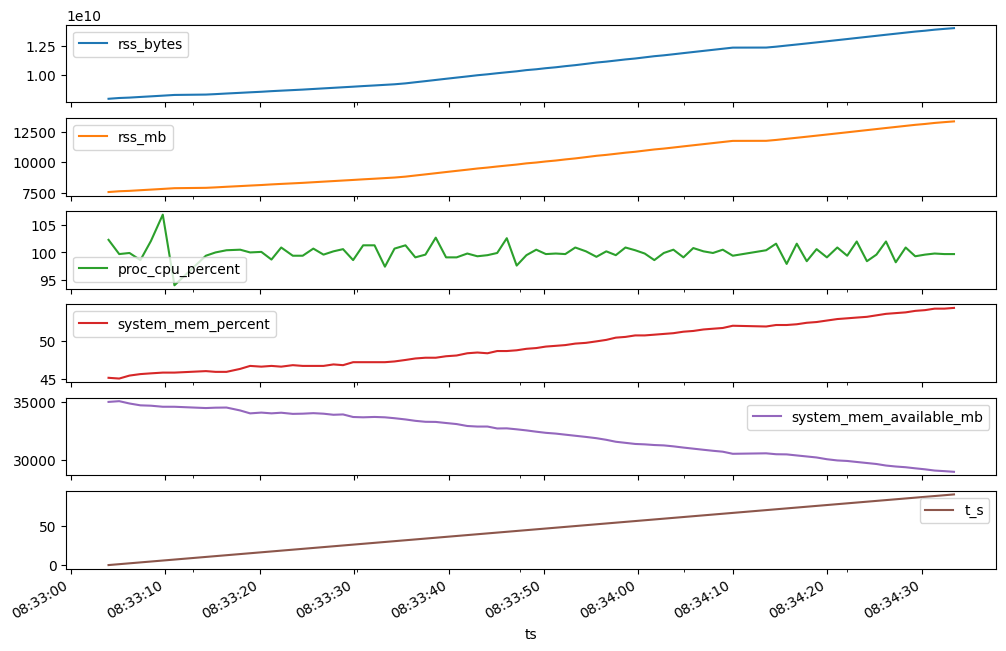

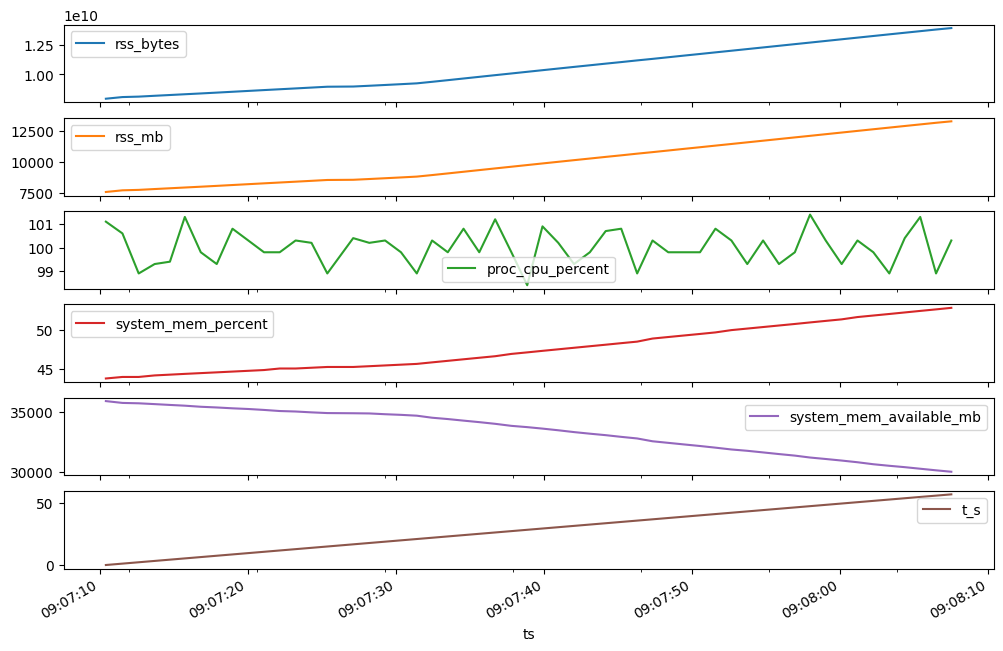

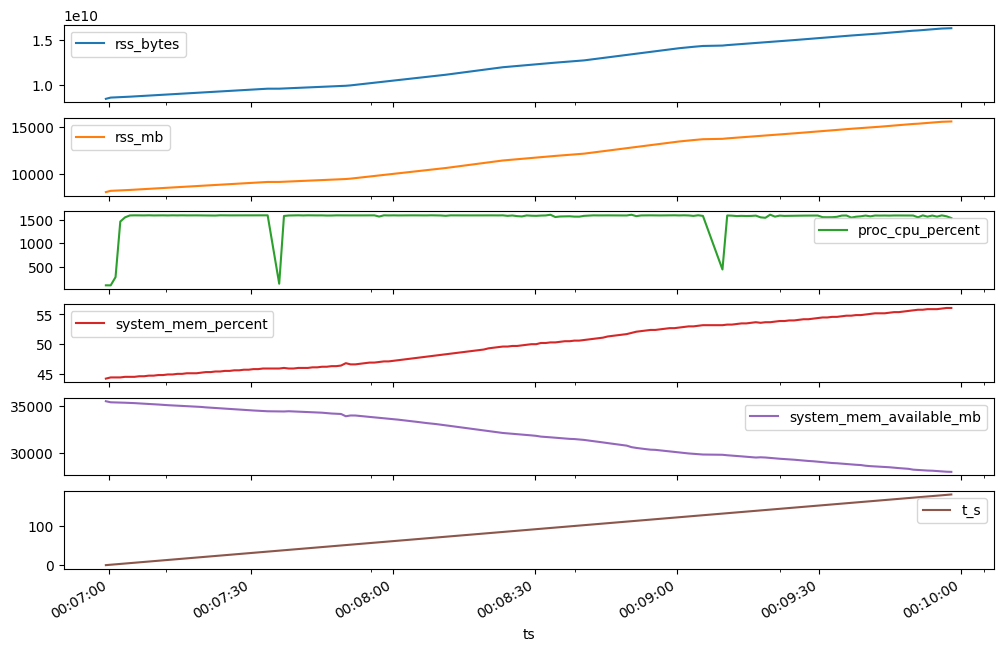

In [ ]:
for file_path in file_paths:
    experiment_name = file_path.stem
    print(f"\n=== {experiment_name} === ")
    exp = experiment_name.split("_")[-2]
    print(f"Experiment: {exp}")
    df = load_monitor_csv(file_path)
    df.set_index('ts').plot(subplots=True, figsize=(12,8))
    summary = summarize_memory(df)
    print(pd.Series(summary))

In [24]:
records = []

for file_path in file_paths:
    experiment_name = file_path.stem
    phase = experiment_name.split("_")[-2]  # "train" or "test"
    
    df = load_monitor_csv(file_path)
    summary = summarize_memory(df)
    
    # Extract model name (adjust parsing as needed)
    # e.g., "darpa_temp_endtoend_base_w10_full_0.001lr_20260526_032241_train_metrics"
    parts = experiment_name.split("_")
    model_name = "_".join(parts[1:-8])  # extract middle portion
    
    records.append({
        "Model": model_name,
        "Phase": phase,
        **summary  # unpack all metrics from summarize_memory()
    })

# Build DataFrame
results_df = pd.DataFrame(records)

# Optional: format for readability
def format_duration(seconds):
    if seconds >= 3600:
        return f"{seconds/3600:.1f}h"
    elif seconds >= 60:
        return f"{seconds/60:.1f}m"
    return f"{seconds:.0f}s"

results_df["time_to_peak"] = results_df["time_to_peak_s"].apply(format_duration)
results_df["peak_gb"] = (results_df["peak_mb"] / 1024).round(2)
results_df["median_gb"] = (results_df["median_mb"] / 1024).round(2)

# Pivot for train/test side-by-side (optional)
display_cols = ["Model", "Phase", "peak_gb", "median_gb", "time_to_peak", "slope_mb_per_s"]
print(results_df[display_cols])


/tmp/ipykernel_296634/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['ts'])
/tmp/ipykernel_296634/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['ts'])
/tmp/ipykernel_296634/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['ts'])
/tmp/ipykernel_296634/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and 

                             Model  Phase  peak_gb  median_gb time_to_peak  \
0                    temp_endtoend  train     7.68       7.68         2.9h   
1                  temp_pretrained  train     7.68       7.68         3.6h   
2   temp_context_baseline_endtoend  train     7.27       7.27         2.6m   
3          temp_context_pretrained   test    15.19      11.15         3.3m   
4            temp_context_endtoend  train     7.84       7.84        45.9m   
5           temp_baseline_endtoend  train     7.32       7.18         1.1m   
6                    temp_endtoend   test    15.31      10.33         2.9m   
7          temp_context_pretrained  train     7.83       7.83        51.7m   
8                  temp_pretrained   test    15.31      10.48         2.7m   
9   temp_context_baseline_endtoend   test    13.03       9.80         1.5m   
10          temp_baseline_endtoend   test    13.00       9.58          57s   
11           temp_context_endtoend   test    15.19      11.35   

/tmp/ipykernel_296634/176223241.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(file_path, parse_dates=['ts'])


In [25]:
# Select and rename columns for clarity
metrics_df = results_df[["Model", "Phase", "peak_gb", "median_gb", "time_to_peak", "slope_mb_per_s"]].copy()

# Pivot to get train/test as column groups
pivot = metrics_df.pivot(index="Model", columns="Phase")

# Flatten multi-level columns
pivot.columns = [f"{metric}_{phase}" for metric, phase in pivot.columns]

# Reorder columns to group by phase
column_order = [
    "peak_gb_train", "median_gb_train", "time_to_peak_train", "slope_mb_per_s_train",
    "peak_gb_test", "median_gb_test", "time_to_peak_test", "slope_mb_per_s_test",
]
pivot = pivot[[c for c in column_order if c in pivot.columns]]

# Sort by model name for readability
pivot = pivot.sort_index()

# Rename columns for cleaner display
pivot.columns = pd.MultiIndex.from_tuples([
    ("Train", "Peak (GB)"), ("Train", "Median (GB)"), ("Train", "Time to Peak"), ("Train", "Slope (MB/s)"),
    ("Test", "Peak (GB)"), ("Test", "Median (GB)"), ("Test", "Time to Peak"), ("Test", "Slope (MB/s)"),
])

print(pivot)


                                   Train                           \
                               Peak (GB) Median (GB) Time to Peak   
Model                                                               
temp_baseline_endtoend              7.32        7.18         1.1m   
temp_context_baseline_endtoend      7.27        7.27         2.6m   
temp_context_endtoend               7.84        7.84        45.9m   
temp_context_pretrained             7.83        7.83        51.7m   
temp_endtoend                       7.68        7.68         2.9h   
temp_pretrained                     7.68        7.68         3.6h   

                                                 Test              \
                               Slope (MB/s) Peak (GB) Median (GB)   
Model                                                               
temp_baseline_endtoend            78.842117     13.00        9.58   
temp_context_baseline_endtoend     1.199394     13.03        9.80   
temp_context_endtoend            